# 4번 세그먼트: 슈퍼노바(Supernova) 최종 정리본

**목적**  
전체 후보군 중 대중성, 팬덤체급, 방송화력이 모두 높은 스트리머를 선별해, CIME의 초기 유입과 플랫폼 인지도를 빠르게 끌어올릴 수 있는 최상위 전략 타깃을 찾는다.

**후보군 기준**
- **65점 이상**: 슈퍼노바 핵심 후보군
- **60점 이상 65점 미만**: 전략 검토 후보군
- **60점 미만**: 일반 후보군

**시각화 구성**
1. 슈퍼노바 핵심 후보군 TOP 20
2. TOP 20 세부 지표별 기여 점수
3. 세부 점수 간 상관관계
4. 원본 지표 간 상관관계
5. 전략 검토군 TOP 50 기반 소속별 대표 후보

## 1. 라이브러리 및 데이터 불러오기

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정: 사용 가능한 폰트 중 먼저 발견되는 것을 적용
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 데이터 경로
DATA_PATH = "../data/final_softcone_for_team.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,소속
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,NaN
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,스텔라이브
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,에스더
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,스텔라이브
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,이세계아이돌


In [21]:
# 데이터 기본 확인
print(df.shape)
df.columns

(11157, 18)


Index(['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅',
       '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수',
       '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자', '소속'],
      dtype='str')

## 2. 슈퍼노바 산식 정의

슈퍼노바는 단순히 방송 성과만 높은 후보가 아니라, **외부 유입 가능성, 팬덤 규모, 실질 방송 화력**을 함께 갖춘 최상위 후보군을 찾는 세그먼트이다.

### 최종 산식

**최종 슈퍼노바 점수 = 대중성 50% + 팬덤체급 25% + 방송화력 25%**

### 세부 점수

**대중성 점수**  
= 유튜브 유입지수 50% + 최고 시청자 30% + 최고 팔로워 20%

**팬덤체급 점수**  
= 유튜브 구독자 40% + 뷰어십 40% + 팬덤지수 20%

**방송화력 점수**  
= 도네이션 40% + 채팅화력 30% + 평균 시청자 30%

### 전처리 기준
- 지표 간 규모 차이가 큰 컬럼은 `log1p` 변환을 적용한다.
- 이후 `MinMaxScaler`를 사용해 0~100점으로 정규화한다.
- 유튜브 유입지수와 팬덤지수는 음수가 나올 수 있으므로 로그 변환하지 않는다.

## 3. 점수 계산

In [22]:
seg4_df = df.copy()

# 점수 계산에 사용할 원본 지표
score_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "팬덤지수",
    "뷰어십",
    "유튜브_구독자"
]

# 수치형 변환 및 결측 처리
for col in score_cols:
    seg4_df[col] = pd.to_numeric(seg4_df[col], errors="coerce").fillna(0)

# 값 차이가 큰 지표는 log1p 변환
log_cols = [
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "뷰어십",
    "유튜브_구독자"
]

for col in log_cols:
    seg4_df[f"log_{col}"] = np.log1p(seg4_df[col])

# 정규화 입력 컬럼과 결과 컬럼은 순서대로 1:1 대응
scale_input_cols = [
    "log_최고_팔로워",
    "log_최고_시청자",
    "유튜브_유입지수",
    "log_도네이션",
    "log_6분_최고채팅",
    "log_평균_시청자_최댓값",
    "팬덤지수",
    "log_뷰어십",
    "log_유튜브_구독자"
]

scaled_cols = [
    "팔로워_score",
    "최고시청자_score",
    "유튜브유입_score",
    "도네이션_score",
    "채팅화력_score",
    "평균시청자_score",
    "팬덤지수_score",
    "뷰어십_score",
    "유튜브구독자_score"
]

scaler = MinMaxScaler(feature_range=(0, 100))
seg4_df[scaled_cols] = scaler.fit_transform(seg4_df[scale_input_cols])

# 1. 대중성 점수
seg4_df["대중성_score"] = (
    seg4_df["유튜브유입_score"] * 0.50 +
    seg4_df["최고시청자_score"] * 0.30 +
    seg4_df["팔로워_score"] * 0.20
)

# 2. 팬덤체급 점수
seg4_df["팬덤체급_score"] = (
    seg4_df["유튜브구독자_score"] * 0.40 +
    seg4_df["뷰어십_score"] * 0.40 +
    seg4_df["팬덤지수_score"] * 0.20
)

# 3. 방송화력 점수
seg4_df["방송화력_score"] = (
    seg4_df["도네이션_score"] * 0.40 +
    seg4_df["채팅화력_score"] * 0.30 +
    seg4_df["평균시청자_score"] * 0.30
)

# 4. 최종 슈퍼노바 점수
seg4_df["세그먼트4_score"] = (
    seg4_df["대중성_score"] * 0.50 +
    seg4_df["팬덤체급_score"] * 0.25 +
    seg4_df["방송화력_score"] * 0.25
)

In [23]:
# 결과 테이블 구성
result_cols = [
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "유튜브_유입지수",
    "유튜브_구독자",
    "팬덤지수",
    "뷰어십",
    "대중성_score",
    "팬덤체급_score",
    "방송화력_score",
    "세그먼트4_score",
    "소속"
]

# 혹시 소속 컬럼이 없을 경우를 대비
if "소속" not in seg4_df.columns:
    seg4_df["소속"] = np.nan

seg4_result = (
    seg4_df[result_cols]
    .sort_values("세그먼트4_score", ascending=False)
    .reset_index(drop=True)
)

seg4_result.head(10)

,스트리머명,플랫폼,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,팬덤체급_score,방송화력_score,세그먼트4_score,소속
0,고세구,SOOP,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,79.165856,98.459542,71.533099,이세계아이돌
1,시라유키 히나,CHZZK,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,76.791456,92.830024,69.715859,스텔라이브
2,주르르,SOOP,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,76.514593,94.612701,69.286628,이세계아이돌
3,비챤,SOOP,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,76.276027,95.924277,69.125035,이세계아이돌
4,아카네 리제,CHZZK,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,76.049127,91.230281,68.983262,스텔라이브
5,탬탬버린,CHZZK,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,53.254149,79.331147,90.016164,68.963902,NaN
6,릴파,SOOP,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,52.441361,77.770914,92.769388,68.855756,이세계아이돌
7,텐코 시부키,CHZZK,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,53.596017,76.910885,91.058295,68.790304,스텔라이브
8,유즈하 리코,CHZZK,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,53.523651,74.852816,91.730136,68.407563,스텔라이브
9,아야츠노 유니,CHZZK,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,52.752609,77.650340,90.381397,68.384239,스텔라이브


## 4. 후보군 기준 설정

슈퍼노바는 최상위 타깃 세그먼트이므로 기준을 너무 넓게 잡으면 컨셉이 약해질 수 있다.  
따라서 **65점 이상은 핵심 후보군**, **60점 이상은 영입 접근 전략을 확인하기 위한 전략 검토군**으로 구분한다.

In [24]:
CORE_CUTOFF = 65
REVIEW_CUTOFF = 60

def supernova_tier(score):
    if score >= CORE_CUTOFF:
        return "슈퍼노바 핵심 후보군"
    elif score >= REVIEW_CUTOFF:
        return "전략 검토 후보군"
    else:
        return "일반 후보군"

seg4_result["슈퍼노바_구분"] = seg4_result["세그먼트4_score"].apply(supernova_tier)

threshold_summary = pd.DataFrame({
    "구분": ["슈퍼노바 핵심 후보군", "전략 검토 후보군", "일반 후보군"],
    "기준": ["65점 이상", "60점 이상 65점 미만", "60점 미만"],
    "용도": [
        "최우선 검토 대상",
        "소속/무소속 영입 접근 전략 검토 대상",
        "일반 후보군"
    ],
    "인원수": [
        (seg4_result["세그먼트4_score"] >= CORE_CUTOFF).sum(),
        ((seg4_result["세그먼트4_score"] >= REVIEW_CUTOFF) & (seg4_result["세그먼트4_score"] < CORE_CUTOFF)).sum(),
        (seg4_result["세그먼트4_score"] < REVIEW_CUTOFF).sum()
    ]
})

threshold_summary

,구분,기준,용도,인원수
0,슈퍼노바 핵심 후보군,65점 이상,최우선 검토 대상,23
1,전략 검토 후보군,60점 이상 65점 미만,소속/무소속 영입 접근 전략 검토 대상,77
2,일반 후보군,60점 미만,일반 후보군,11057


In [25]:
# 핵심 후보군 확인
core_candidates = (
    seg4_result[seg4_result["세그먼트4_score"] >= CORE_CUTOFF]
    .sort_values("세그먼트4_score", ascending=False)
    .copy()
)

core_candidates.head(30)

,스트리머명,플랫폼,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,팬덤체급_score,방송화력_score,세그먼트4_score,소속,슈퍼노바_구분
0,고세구,SOOP,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,79.165856,98.459542,71.533099,이세계아이돌,슈퍼노바 핵심 후보군
1,시라유키 히나,CHZZK,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,76.791456,92.830024,69.715859,스텔라이브,슈퍼노바 핵심 후보군
2,주르르,SOOP,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,76.514593,94.612701,69.286628,이세계아이돌,슈퍼노바 핵심 후보군
3,비챤,SOOP,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,76.276027,95.924277,69.125035,이세계아이돌,슈퍼노바 핵심 후보군
4,아카네 리제,CHZZK,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,76.049127,91.230281,68.983262,스텔라이브,슈퍼노바 핵심 후보군
5,탬탬버린,CHZZK,308659,23115,6876167,5923,13532,4.4,537000,-13.9,17075004,53.254149,79.331147,90.016164,68.963902,NaN,슈퍼노바 핵심 후보군
6,릴파,SOOP,185167,21790,5796867,13983,18865,7.0,434000,10.5,7788723,52.441361,77.770914,92.769388,68.855756,이세계아이돌,슈퍼노바 핵심 후보군
7,텐코 시부키,CHZZK,222276,34645,6737178,7255,16465,-0.7,204000,4.1,14216251,53.596017,76.910885,91.058295,68.790304,스텔라이브,슈퍼노바 핵심 후보군
8,유즈하 리코,CHZZK,183957,36983,6609127,7092,21539,0.0,183000,5.6,6673506,53.523651,74.852816,91.730136,68.407563,스텔라이브,슈퍼노바 핵심 후보군
9,아야츠노 유니,CHZZK,281741,21414,6715398,6674,14086,1.7,347000,2.8,10770780,52.752609,77.650340,90.381397,68.384239,스텔라이브,슈퍼노바 핵심 후보군


## 5. 시각화 1: 슈퍼노바 핵심 후보군 TOP 20

65점 이상 핵심 후보군 중 상위 20명을 확인한다.  
이 그래프는 슈퍼노바 점수가 높은 최우선 검토 대상을 보여준다.

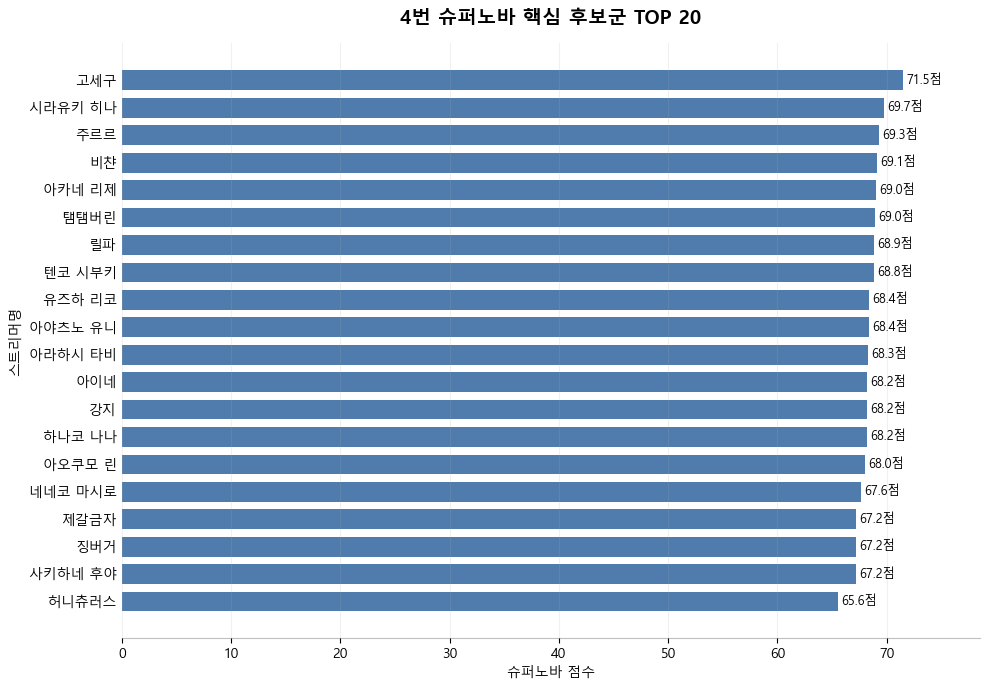

In [26]:
top20 = (
    seg4_result[seg4_result["세그먼트4_score"] >= CORE_CUTOFF]
    .sort_values("세그먼트4_score", ascending=False)
    .head(20)
    .copy()
)

plt.figure(figsize=(10, 7), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

plt.barh(
    top20["스트리머명"],
    top20["세그먼트4_score"],
    color="#4F7CAC",
    height=0.72
)

for i, score in enumerate(top20["세그먼트4_score"]):
    plt.text(
        score + 0.3,
        i,
        f"{score:.1f}점",
        va="center",
        fontsize=9
    )

plt.xlabel("슈퍼노바 점수")
plt.ylabel("스트리머명")
plt.title("4번 슈퍼노바 핵심 후보군 TOP 20", fontsize=14, fontweight="bold", pad=14)

plt.gca().invert_yaxis()
plt.xlim(0, top20["세그먼트4_score"].max() + 7)

plt.grid(axis="x", alpha=0.18)
plt.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.25)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 6. 시각화 2: TOP 20 세부 지표별 기여 점수

TOP 20 후보의 최종 점수를 **대중성, 팬덤체급, 방송화력**으로 분해해 확인한다.  
이 그래프는 단순 순위가 아니라, 각 후보가 어떤 강점 구조로 상위권에 위치했는지 보여준다.

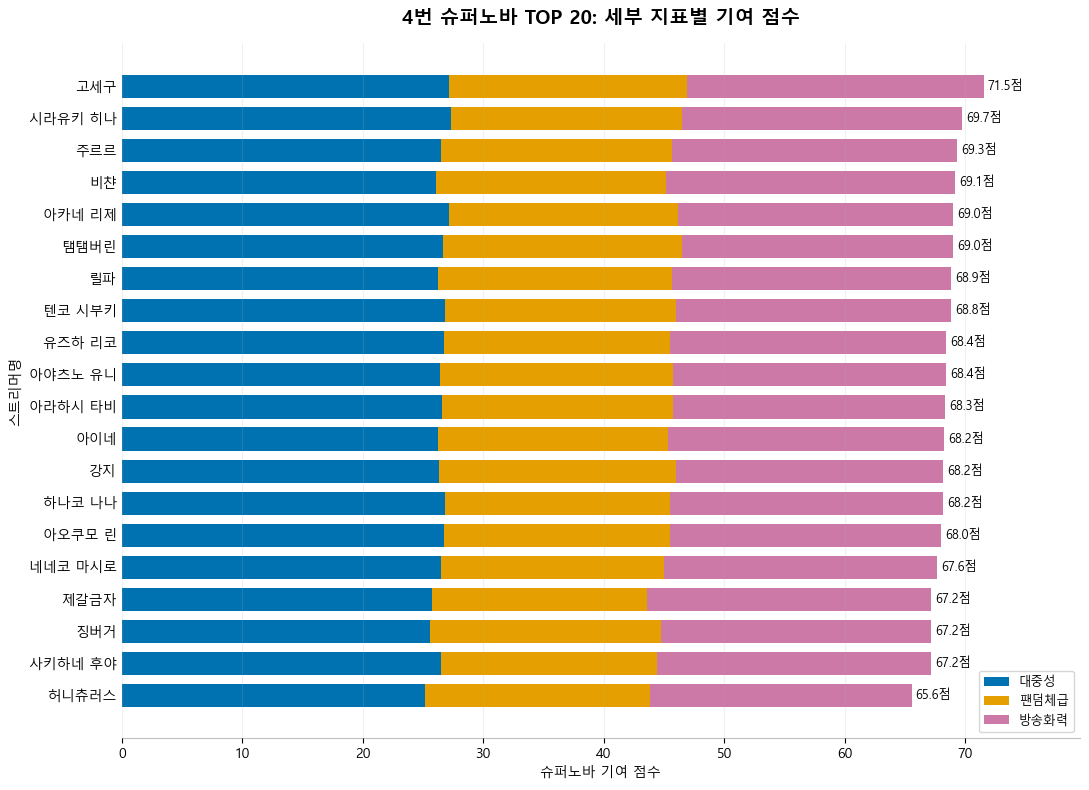

In [27]:
# 최종 산식과 동일한 가중치로 기여 점수 계산
top20["대중성_기여점수"] = top20["대중성_score"] * 0.50
top20["팬덤체급_기여점수"] = top20["팬덤체급_score"] * 0.25
top20["방송화력_기여점수"] = top20["방송화력_score"] * 0.25

contribution_cols = [
    "대중성_기여점수",
    "팬덤체급_기여점수",
    "방송화력_기여점수"
]

labels = {
    "대중성_기여점수": "대중성",
    "팬덤체급_기여점수": "팬덤체급",
    "방송화력_기여점수": "방송화력"
}

colors = {
    "대중성_기여점수": "#0072B2",   # 파랑
    "팬덤체급_기여점수": "#E69F00", # 주황
    "방송화력_기여점수": "#CC79A7"  # 보라
}

plt.figure(figsize=(11, 8), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

left = np.zeros(len(top20))

for col in contribution_cols:
    plt.barh(
        top20["스트리머명"],
        top20[col],
        left=left,
        label=labels[col],
        color=colors[col],
        height=0.72
    )
    left += top20[col].values

for i, score in enumerate(top20["세그먼트4_score"]):
    plt.text(
        score + 0.35,
        i,
        f"{score:.1f}점",
        va="center",
        fontsize=9
    )

plt.xlabel("슈퍼노바 기여 점수")
plt.ylabel("스트리머명")
plt.title("4번 슈퍼노바 TOP 20: 세부 지표별 기여 점수", fontsize=14, fontweight="bold", pad=14)
plt.legend(loc="lower right", frameon=True, fontsize=9)

plt.xlim(0, top20["세그먼트4_score"].max() + 8)
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.18)
plt.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.25)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 7. EDA 근거 1: 세부 점수 간 상관관계

로그 변환 및 정규화 이후 계산된 대중성·팬덤체급·방송화력 점수가 최종 슈퍼노바 점수와 어떻게 연결되는지 확인한다.

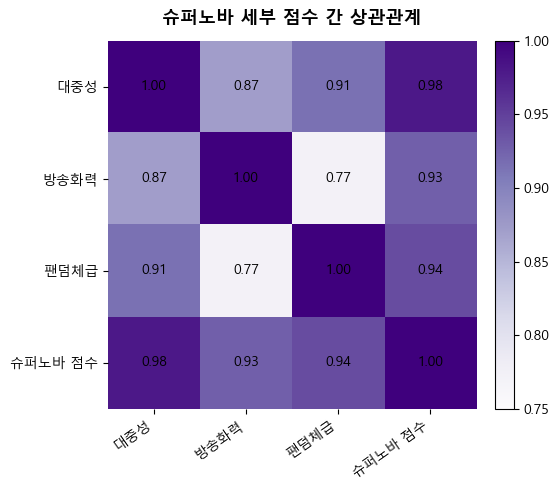

,대중성_score,방송화력_score,팬덤체급_score,세그먼트4_score
대중성_score,1.000000,0.871480,0.914533,0.980043
방송화력_score,0.871480,1.000000,0.771067,0.927518
팬덤체급_score,0.914533,0.771067,1.000000,0.940805
세그먼트4_score,0.980043,0.927518,0.940805,1.000000


In [28]:
score_corr_cols = [
    "대중성_score",
    "방송화력_score",
    "팬덤체급_score",
    "세그먼트4_score"
]

corr_matrix = seg4_result[score_corr_cols].corr()

plt.figure(figsize=(6, 5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

im = plt.imshow(
    corr_matrix,
    cmap="Purples",
    vmin=0.75,
    vmax=1.00
)

axis_labels = ["대중성", "방송화력", "팬덤체급", "슈퍼노바 점수"]

plt.xticks(range(len(score_corr_cols)), axis_labels, rotation=35, ha="right")
plt.yticks(range(len(score_corr_cols)), axis_labels)

for i in range(len(score_corr_cols)):
    for j in range(len(score_corr_cols)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=10)

plt.title("슈퍼노바 세부 점수 간 상관관계", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

corr_matrix

## 8. EDA 근거 2: 원본 지표 간 상관관계

원본 지표 간 관계를 확인해 슈퍼노바 산식에 사용한 지표들이 어떤 성격을 갖는지 점검한다.  
특히 시청자·팔로워·뷰어십·도네이션 등 체급 지표가 함께 움직이는지, 유튜브 유입지수와 팬덤지수가 별도 관점을 보완하는지 확인한다.

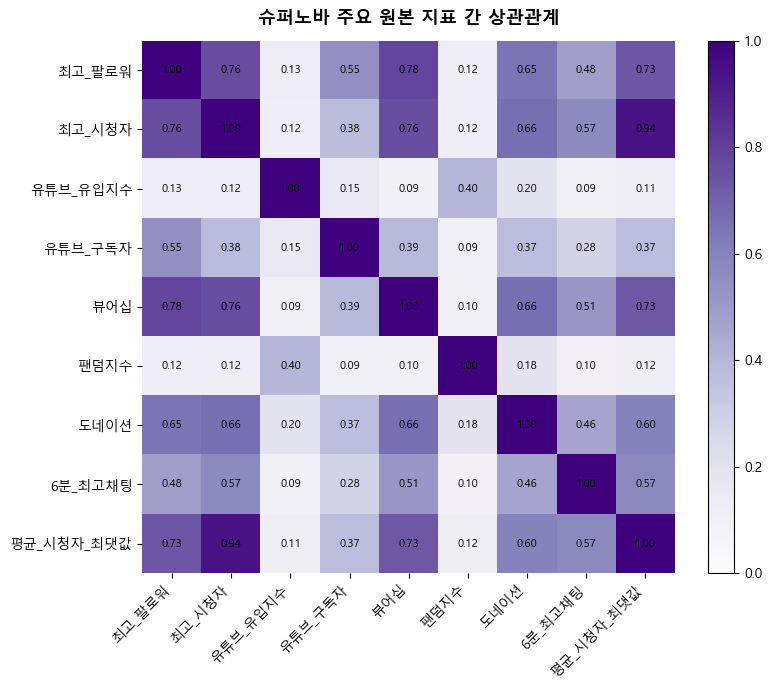

,최고_팔로워,최고_시청자,유튜브_유입지수,유튜브_구독자,뷰어십,팬덤지수,도네이션,6분_최고채팅,평균_시청자_최댓값
최고_팔로워,1.000000,0.762207,0.128720,0.545735,0.781668,0.117503,0.648312,0.481312,0.732406
최고_시청자,0.762207,1.000000,0.117550,0.376364,0.757517,0.119160,0.664660,0.567142,0.936506
유튜브_유입지수,0.128720,0.117550,1.000000,0.149847,0.091087,0.400628,0.198205,0.093004,0.110417
유튜브_구독자,0.545735,0.376364,0.149847,1.000000,0.390423,0.091193,0.371761,0.280858,0.373757
뷰어십,0.781668,0.757517,0.091087,0.390423,1.000000,0.100050,0.664935,0.512050,0.729331
팬덤지수,0.117503,0.119160,0.400628,0.091193,0.100050,1.000000,0.183630,0.095732,0.115290
도네이션,0.648312,0.664660,0.198205,0.371761,0.664935,0.183630,1.000000,0.462310,0.597942
6분_최고채팅,0.481312,0.567142,0.093004,0.280858,0.512050,0.095732,0.462310,1.000000,0.573474
평균_시청자_최댓값,0.732406,0.936506,0.110417,0.373757,0.729331,0.115290,0.597942,0.573474,1.000000


In [29]:
raw_corr_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "유튜브_구독자",
    "뷰어십",
    "팬덤지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값"
]

raw_corr = seg4_df[raw_corr_cols].corr()

plt.figure(figsize=(9, 7), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

im = plt.imshow(raw_corr, cmap="Purples", vmin=0, vmax=1)

plt.xticks(range(len(raw_corr_cols)), raw_corr_cols, rotation=45, ha="right")
plt.yticks(range(len(raw_corr_cols)), raw_corr_cols)

for i in range(len(raw_corr_cols)):
    for j in range(len(raw_corr_cols)):
        value = raw_corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title("슈퍼노바 주요 원본 지표 간 상관관계", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

raw_corr

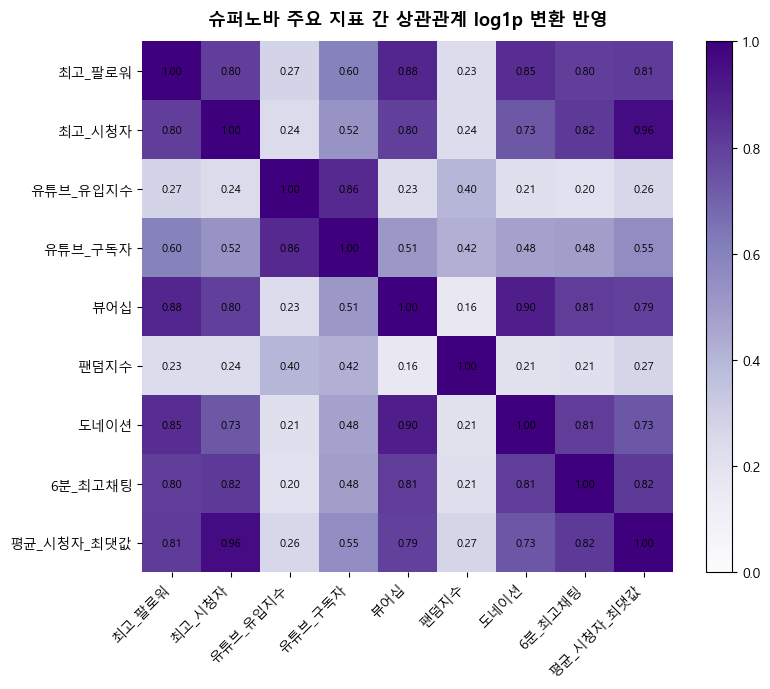

,최고_팔로워,최고_시청자,유튜브_유입지수,유튜브_구독자,뷰어십,팬덤지수,도네이션,6분_최고채팅,평균_시청자_최댓값
최고_팔로워,1.000000,0.803615,0.274558,0.599551,0.878184,0.234177,0.852605,0.801844,0.810331
최고_시청자,0.803615,1.000000,0.239232,0.523743,0.799370,0.235044,0.728390,0.815482,0.963582
유튜브_유입지수,0.274558,0.239232,1.000000,0.864219,0.231419,0.400628,0.212109,0.201209,0.263276
유튜브_구독자,0.599551,0.523743,0.864219,1.000000,0.508830,0.420359,0.475721,0.480511,0.550984
뷰어십,0.878184,0.799370,0.231419,0.508830,1.000000,0.163548,0.901108,0.805484,0.794253
팬덤지수,0.234177,0.235044,0.400628,0.420359,0.163548,1.000000,0.205836,0.212910,0.270373
도네이션,0.852605,0.728390,0.212109,0.475721,0.901108,0.205836,1.000000,0.805330,0.733619
6분_최고채팅,0.801844,0.815482,0.201209,0.480511,0.805484,0.212910,0.805330,1.000000,0.816311
평균_시청자_최댓값,0.810331,0.963582,0.263276,0.550984,0.794253,0.270373,0.733619,0.816311,1.000000


In [30]:
raw_corr_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "유튜브_구독자",
    "뷰어십",
    "팬덤지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값"
]

# 로그 변환할 지표
log_target_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_구독자",
    "뷰어십",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값"
]

# 상관관계 확인용 데이터 복사
log_corr_df = seg4_df[raw_corr_cols].copy()

# 큰 수치 지표만 log1p 변환
for col in log_target_cols:
    log_corr_df[col] = np.log1p(log_corr_df[col])

log_corr = log_corr_df.corr()

plt.figure(figsize=(9, 7), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

im = plt.imshow(log_corr, cmap="Purples", vmin=0, vmax=1)

plt.xticks(range(len(raw_corr_cols)), raw_corr_cols, rotation=45, ha="right")
plt.yticks(range(len(raw_corr_cols)), raw_corr_cols)

for i in range(len(raw_corr_cols)):
    for j in range(len(raw_corr_cols)):
        value = log_corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title("슈퍼노바 주요 지표 간 상관관계 log1p 변환 반영", fontsize=13, fontweight="bold", pad=12)
plt.colorbar(im, fraction=0.046, pad=0.04)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

log_corr

## 9. 전략 검토군 TOP 50 기반 소속별 대표 후보

65점 이상은 핵심 후보군으로 우선 검토하고, 60점 이상 후보는 소속/무소속 접근 전략을 확인하기 위한 전략 검토 범위로 활용한다.

표시 기준:
- 전체 후보군에서 60점 이상 후보 중 상위 50명을 확인한다.
- 동일 소속 후보는 하나의 그룹으로 묶는다.
- 소속 그룹은 해당 소속 내 슈퍼노바 점수가 가장 높은 스트리머를 대표 후보로 표시한다.
- 무소속 후보는 개별 스트리머 단위로 유지한다.

In [31]:
# 전략 검토 범위: 60점 이상 후보 중 상위 50명
strategy_top50 = (
    seg4_result[seg4_result["세그먼트4_score"] >= REVIEW_CUTOFF]
    .sort_values("세그먼트4_score", ascending=False)
    .head(50)
    .copy()
)

# 소속 정리: NaN, 빈 문자열, "없음" → "무소속"
strategy_top50["소속_표시"] = (
    strategy_top50["소속"]
    .astype("string")
    .str.strip()
    .replace(["", "없음", "nan", "<NA>"], pd.NA)
    .fillna("무소속")
)

# 소속이 있으면 소속명으로 묶고, 무소속이면 스트리머명으로 개별 표시
strategy_top50["표시그룹"] = strategy_top50.apply(
    lambda row: row["스트리머명"] if row["소속_표시"] == "무소속" else row["소속_표시"],
    axis=1
)

strategy_top50.head()

,스트리머명,플랫폼,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,유튜브_구독자,팬덤지수,뷰어십,대중성_score,팬덤체급_score,방송화력_score,세그먼트4_score,소속,슈퍼노바_구분,소속_표시,표시그룹
0,고세구,SOOP,199696,39102,5905590,95063,23877,8.2,545000,9.8,10855404,54.253498,79.165856,98.459542,71.533099,이세계아이돌,슈퍼노바 핵심 후보군,이세계아이돌,이세계아이돌
1,시라유키 히나,CHZZK,219675,47218,6864206,6960,30958,2.6,302000,4.4,8608945,54.620978,76.791456,92.830024,69.715859,스텔라이브,슈퍼노바 핵심 후보군,스텔라이브,스텔라이브
2,주르르,SOOP,175519,27415,3250999,55406,17295,7.2,417000,11.0,4794346,53.009609,76.514593,94.612701,69.286628,이세계아이돌,슈퍼노바 핵심 후보군,이세계아이돌,이세계아이돌
3,비챤,SOOP,176315,20891,2862540,108416,16694,5.2,331000,10.9,5657369,52.149919,76.276027,95.924277,69.125035,이세계아이돌,슈퍼노바 핵심 후보군,이세계아이돌,이세계아이돌
4,아카네 리제,CHZZK,235506,40960,6069644,5873,23109,2.5,319000,3.9,5983879,54.326821,76.049127,91.230281,68.983262,스텔라이브,슈퍼노바 핵심 후보군,스텔라이브,스텔라이브


In [32]:
# 표시그룹별 후보 수
group_count = (
    strategy_top50
    .groupby("표시그룹")
    .size()
    .reset_index(name="후보수")
)

# 표시그룹별 대표 후보: 같은 소속 안에서는 슈퍼노바 점수가 가장 높은 후보 1명 선정
group_rep = (
    strategy_top50
    .sort_values("세그먼트4_score", ascending=False)
    .groupby("표시그룹", as_index=False)
    .first()
    [["표시그룹", "스트리머명", "소속_표시", "세그먼트4_score"]]
    .rename(columns={
        "스트리머명": "대표스트리머",
        "세그먼트4_score": "대표점수"
    })
)

supernova_group_result = (
    group_rep
    .merge(group_count, on="표시그룹", how="left")
    .sort_values("대표점수", ascending=False)
    .reset_index(drop=True)
)

supernova_group_result["대표점수"] = supernova_group_result["대표점수"].round(1)

supernova_group_result

,표시그룹,대표스트리머,소속_표시,대표점수,후보수
0,이세계아이돌,고세구,이세계아이돌,71.5,6
1,스텔라이브,시라유키 히나,스텔라이브,69.7,11
2,탬탬버린,탬탬버린,무소속,69.0,1
3,블루점프,제갈금자,블루점프,67.2,1
4,프로젝트아이,허니츄러스,프로젝트아이,65.6,2
5,천양,천양,무소속,65.4,1
6,에스더,아리사,에스더,65.3,3
7,민결희,민결희,무소속,65.1,1
8,마이곰이,마이곰이,무소속,64.9,1
9,유소나,유소나,무소속,64.7,1


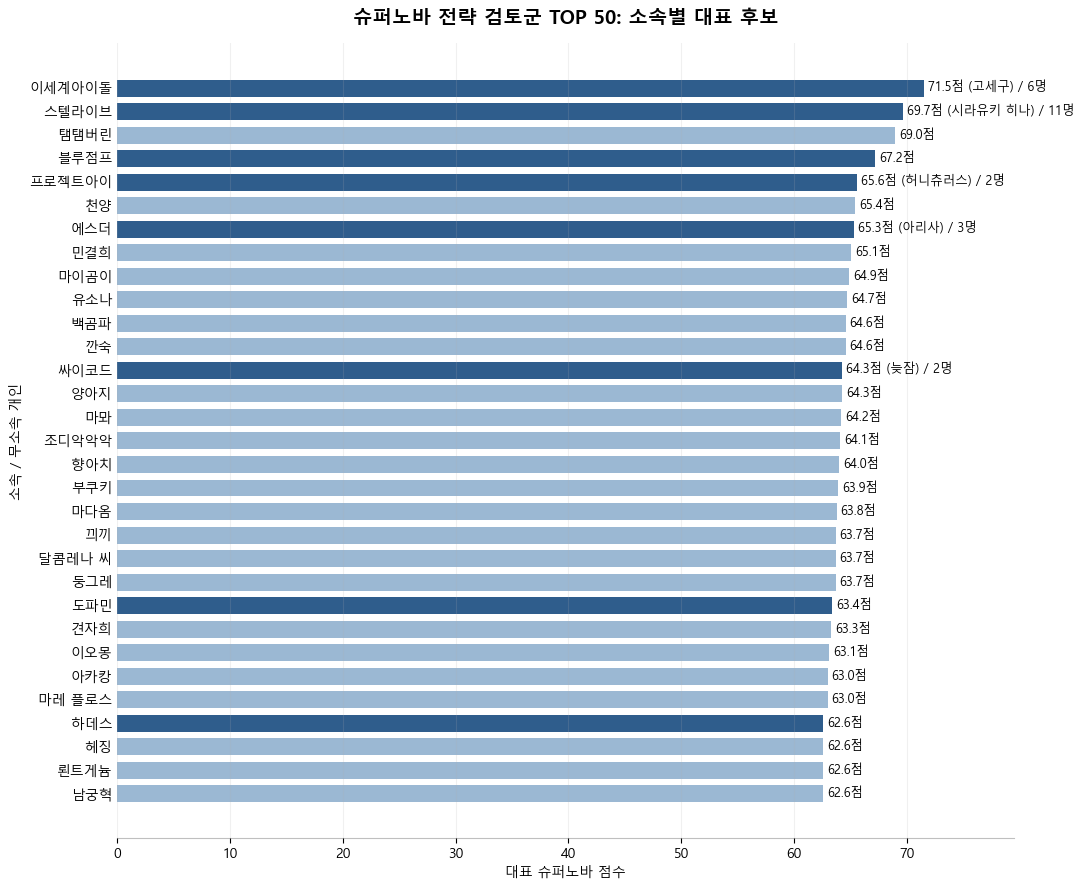

In [34]:
plot_df = supernova_group_result.sort_values("대표점수", ascending=True).copy()

# 소속 그룹은 진한색, 무소속 개인은 연한색
group_color = "#2F5D8C"
solo_color = "#9BB8D3"

colors = [
    solo_color if 소속 == "무소속" else group_color
    for 소속 in plot_df["소속_표시"]
]

plt.figure(figsize=(11, 9), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

plt.barh(
    plot_df["표시그룹"],
    plot_df["대표점수"],
    color=colors,
    height=0.72
)

for i, row in enumerate(plot_df.itertuples()):
    if row.후보수 > 1:
        label = f"{row.대표점수:.1f}점 ({row.대표스트리머}) / {row.후보수}명"
    else:
        label = f"{row.대표점수:.1f}점"
    
    plt.text(
        row.대표점수 + 0.35,
        i,
        label,
        va="center",
        fontsize=9
    )

plt.title("슈퍼노바 전략 검토군 TOP 50: 소속별 대표 후보", fontsize=14, fontweight="bold", pad=14)
plt.xlabel("대표 슈퍼노바 점수")
plt.ylabel("소속 / 무소속 개인")
plt.xlim(0, plot_df["대표점수"].max() + 8)

plt.grid(axis="x", alpha=0.18)
plt.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_alpha(0.25)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 10. 최종 인사이트

슈퍼노바 세그먼트는 전체 후보군 중 대중성, 팬덤체급, 방송화력을 종합적으로 평가해\
CIME의 초기 유입과 플랫폼 인지도 상승에 기여할 가능성이 높은 최상위 후보군을 선별하기 위한 분석이다.

최종 슈퍼노바 점수는 대중성을 가장 크게 반영하고,\
팬덤체급과 방송화력을 함께 고려해 단순 인기 지표가 아니라\
외부 유입 가능성, 팬덤 기반, 실제 방송 성과를 함께 검토하도록 설계했다.

분석 결과, 65점 이상 후보는 슈퍼노바 핵심 후보군으로 정의하고,\
60점 이상 후보는 영입 접근 전략을 확인하기 위한 전략 검토군으로 구분했다.

또한 동일 소속 후보는 하나의 그룹으로 묶고,\
그 안에서 슈퍼노바 점수가 가장 높은 스트리머를 대표 후보로 표시했다.\
반면 무소속 후보는 하나의 집단으로 묶지 않고 개별 스트리머 단위로 유지했다.

따라서 슈퍼노바 분석은 단순히 점수 순위를 나열하는 것이 아니라,\
CIME이 우선적으로 주목해야 할 핵심 후보군과\
소속 단위·개인 단위의 영입 접근 전략을 함께 정리하는 데 의미가 있다.